# ML: Предиктивное техническое обслуживание роботов

**Задача:** бинарная классификация — предсказать, произойдёт ли подтверждённый отказ робота  
в течение следующих 30 дней (`has_failure_next_30d`).

**Подход:**
1. **Gold Layer** — построить feature dataset на базе Silver-таблиц (окно признаков: 90 дней назад, горизонт цели: 30 дней вперёд)
2. **Baseline** — Logistic Regression
3. **Основная модель** — Gradient Boosting
4. **Оценка** — ROC-AUC, Precision-Recall, анализ порогов, бизнес-метрики

**Важно:** признаки рассчитываются только по данным до `feature_date`,  
целевая переменная смотрит только в будущее — утечки (target leakage) нет.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pathlib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110})

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

SILVER = 'data/silver'
GOLD   = 'data/gold'
pathlib.Path(GOLD).mkdir(exist_ok=True)

con = duckdb.connect()
print('OK — все библиотеки загружены')

OK — все библиотеки загружены


---
## 1. Gold Layer — построение feature dataset

Для каждого робота генерируем еженедельные срезы (`feature_date` = каждый понедельник).  
Эффективный период: **2025-12-01 → 2026-04-01** (30 дней буфер с каждой стороны от границ данных).

| Группа | Признаки |
|---|---|
| Износ расходников | `brush/filter/squeegee_residual_last` |
| Активность | `missions_7d/30d`, `area_30d/90d` |
| Качество миссий | `avg_completion_7d/30d`, `avg_battery_drop_30d` |
| История ТО | `days_since_last_maintenance/failure`, `maint/failure_count`, `downtime_30d` |
| Батарея | `battery_cycle_times_last`, `avg_battery_soc_7d`, `battery_aging` |

In [2]:
FEATURE_SQL = f"""
WITH feature_dates AS (
    SELECT DISTINCT
        robot_serial_number                         AS serial_number,
        date_trunc('week', start_time::DATE)::DATE  AS feature_date
    FROM read_parquet('{SILVER}/task_reports/dt=*/*.parquet')
    WHERE start_time::DATE BETWEEN '2025-12-01' AND '2026-04-01'
),

-- Агрегация status до дня, чтобы избежать join 149K строк на каждый feature_date
status_daily AS (
    SELECT
        serial_number,
        dt,
        AVG(battery_soc)                      AS avg_battery_soc,
        ARG_MAX(battery_cycle_times, poll_ts)  AS battery_cycle_times,
        ARG_MAX(battery_health, poll_ts)       AS battery_health
    FROM read_parquet('{SILVER}/robot_status/dt=*/*.parquet')
    GROUP BY serial_number, dt
),

task_feat AS (
    SELECT
        fd.serial_number,
        fd.feature_date,
        -- Последний известный остаток ресурса расходников
        ARG_MAX(t.brush_residual_pct,         t.start_time)  AS brush_residual_last,
        ARG_MAX(t.filter_residual_pct,        t.start_time)  AS filter_residual_last,
        ARG_MAX(t.suction_blade_residual_pct, t.start_time)  AS squeegee_residual_last,
        -- Частота миссий
        COUNT(*) FILTER (WHERE t.start_time::DATE >= fd.feature_date - 7)   AS missions_7d,
        COUNT(*) FILTER (WHERE t.start_time::DATE >= fd.feature_date - 30)  AS missions_30d,
        -- Убранная площадь
        COALESCE(SUM(t.actual_area_m2) FILTER (
            WHERE t.start_time::DATE >= fd.feature_date - 30), 0)            AS area_30d,
        COALESCE(SUM(t.actual_area_m2) FILTER (
            WHERE t.start_time::DATE >= fd.feature_date - 90), 0)            AS area_90d,
        -- Качество выполнения
        AVG(t.completion_percentage) FILTER (
            WHERE t.start_time::DATE >= fd.feature_date - 7)                 AS avg_completion_7d,
        AVG(t.completion_percentage) FILTER (
            WHERE t.start_time::DATE >= fd.feature_date - 30)                AS avg_completion_30d,
        AVG(t.battery_delta_pct) FILTER (
            WHERE t.start_time::DATE >= fd.feature_date - 30)                AS avg_battery_drop_30d
    FROM feature_dates fd
    JOIN read_parquet('{SILVER}/task_reports/dt=*/*.parquet') t
        ON t.robot_serial_number = fd.serial_number
       AND t.start_time::DATE <  fd.feature_date
       AND t.start_time::DATE >= fd.feature_date - 90
    GROUP BY fd.serial_number, fd.feature_date
),

maint_feat AS (
    SELECT
        fd.serial_number,
        fd.feature_date,
        COALESCE(datediff('day',
            MAX(m.completed_at::DATE) FILTER (WHERE m.completed_at::DATE < fd.feature_date),
            fd.feature_date), 999)                                                         AS days_since_last_maintenance,
        COALESCE(datediff('day',
            MAX(m.completed_at::DATE) FILTER (WHERE m.completed_at::DATE < fd.feature_date
                                                AND m.failure_detected),
            fd.feature_date), 999)                                                         AS days_since_last_failure,
        COUNT(*) FILTER (WHERE m.completed_at::DATE >= fd.feature_date - 30
                           AND m.completed_at::DATE <  fd.feature_date)                    AS maint_count_30d,
        COUNT(*) FILTER (WHERE m.completed_at::DATE >= fd.feature_date - 90
                           AND m.completed_at::DATE <  fd.feature_date)                    AS maint_count_90d,
        COALESCE(SUM(m.downtime_minutes) FILTER (
            WHERE m.completed_at::DATE >= fd.feature_date - 30
              AND m.completed_at::DATE <  fd.feature_date), 0)                             AS downtime_30d,
        COUNT(*) FILTER (WHERE m.failure_detected
                           AND m.completed_at::DATE >= fd.feature_date - 90
                           AND m.completed_at::DATE <  fd.feature_date)                    AS failure_count_90d,
        COUNT(*) FILTER (WHERE m.maintenance_type = 'corrective'
                           AND m.completed_at::DATE >= fd.feature_date - 90
                           AND m.completed_at::DATE <  fd.feature_date)                    AS corrective_count_90d
    FROM feature_dates fd
    LEFT JOIN read_parquet('{SILVER}/maintenance_events/dt=*/*.parquet') m
        ON m.robot_id = fd.serial_number
    GROUP BY fd.serial_number, fd.feature_date
),

status_feat AS (
    SELECT
        fd.serial_number,
        fd.feature_date,
        ARG_MAX(sd.battery_cycle_times, sd.dt)  AS battery_cycle_times_last,
        ARG_MAX(sd.battery_health,      sd.dt)  AS battery_health_last,
        AVG(sd.avg_battery_soc)                 AS avg_battery_soc_7d
    FROM feature_dates fd
    JOIN status_daily sd
        ON sd.serial_number = fd.serial_number
       AND sd.dt <  fd.feature_date
       AND sd.dt >= fd.feature_date - 7
    GROUP BY fd.serial_number, fd.feature_date
),

target AS (
    SELECT
        fd.serial_number,
        fd.feature_date,
        COALESCE(MAX(CASE WHEN m.failure_detected THEN 1 ELSE 0 END), 0) AS has_failure_next_30d
    FROM feature_dates fd
    LEFT JOIN read_parquet('{SILVER}/maintenance_events/dt=*/*.parquet') m
        ON m.robot_id = fd.serial_number
       AND m.completed_at::DATE >  fd.feature_date
       AND m.completed_at::DATE <= fd.feature_date + 30
    GROUP BY fd.serial_number, fd.feature_date
)

SELECT
    tf.serial_number,
    tf.feature_date,
    tf.brush_residual_last,
    tf.filter_residual_last,
    tf.squeegee_residual_last,
    tf.missions_7d,
    tf.missions_30d,
    tf.area_30d,
    tf.area_90d,
    tf.avg_completion_7d,
    tf.avg_completion_30d,
    tf.avg_battery_drop_30d,
    mf.days_since_last_maintenance,
    mf.days_since_last_failure,
    mf.maint_count_30d,
    mf.maint_count_90d,
    mf.downtime_30d,
    mf.failure_count_90d,
    mf.corrective_count_90d,
    sf.battery_cycle_times_last,
    sf.battery_health_last,
    sf.avg_battery_soc_7d,
    t.has_failure_next_30d
FROM task_feat tf
LEFT JOIN maint_feat   mf ON mf.serial_number = tf.serial_number AND mf.feature_date = tf.feature_date
LEFT JOIN status_feat  sf ON sf.serial_number = tf.serial_number AND sf.feature_date = tf.feature_date
LEFT JOIN target        t ON t.serial_number  = tf.serial_number AND t.feature_date  = tf.feature_date
ORDER BY tf.serial_number, tf.feature_date
"""

gold = con.execute(FEATURE_SQL).df()
gold.to_parquet(f'{GOLD}/robot_features.parquet', index=False)

print(f'Gold dataset: {gold.shape[0]} строк × {gold.shape[1]} колонок')
print(f'Сохранён в {GOLD}/robot_features.parquet')
print(f'\nПериод:  {gold.feature_date.min()} — {gold.feature_date.max()}')
print(f'Роботов: {gold.serial_number.nunique()}')
display(gold.head(3))

Gold dataset: 216 строк × 23 колонок
Сохранён в data/gold/robot_features.parquet

Период:  2025-12-01 00:00:00 — 2026-03-30 00:00:00
Роботов: 12


,serial_number,feature_date,brush_residual_last,filter_residual_last,squeegee_residual_last,missions_7d,missions_30d,area_30d,area_90d,avg_completion_7d,...,days_since_last_failure,maint_count_30d,maint_count_90d,downtime_30d,failure_count_90d,corrective_count_90d,battery_cycle_times_last,battery_health_last,avg_battery_soc_7d,has_failure_next_30d
0,CB300-2200-W5R-0001,2025-12-01,0,48,10,50,193,125685.643,125685.643,0.632600,...,26,2,2,295.0,1,1,177,HEALTHY,51.339545,1
1,CB300-2200-W5R-0001,2025-12-08,0,38,0,48,207,125965.167,151239.265,0.599958,...,33,0,2,0.0,1,1,182,HEALTHY,55.184265,1
2,CB300-2200-W5R-0001,2025-12-15,0,29,0,46,206,116420.599,173794.731,0.547087,...,1,1,3,228.0,2,2,186,AGING,53.310559,1


Пропуски по колонкам:
  нет

Размер датасета: (216, 23)

Баланс классов:
  Нет отказа (0):  110  (50.9%)
  Отказ     (1):  106  (49.1%)


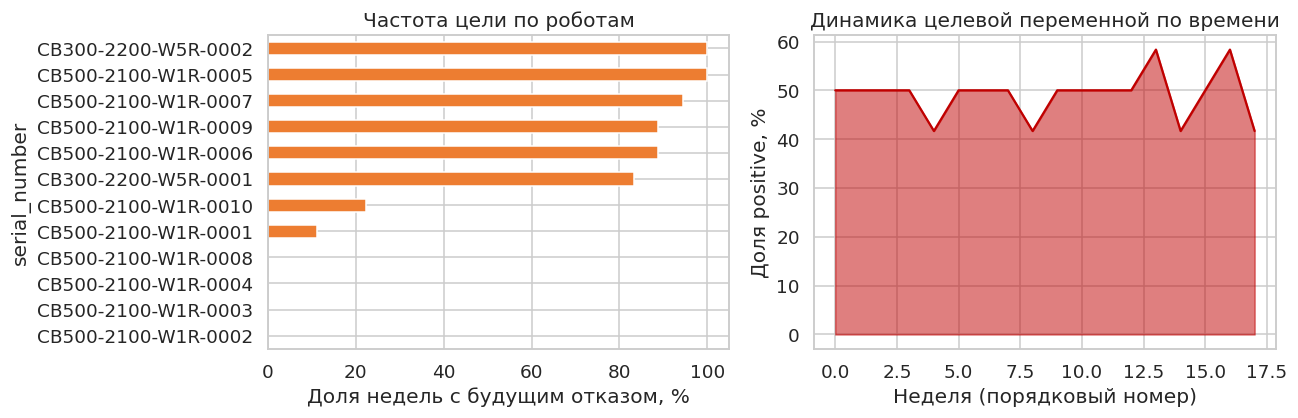

In [3]:
# Post-processing: типизация и заполнение пропусков
gold['battery_aging'] = (gold['battery_health_last'] == 'AGING').astype(int)
gold = gold.drop(columns=['battery_health_last'])

# Если нет данных о расходниках за последние 90 дней — считаем "как новый" (100%)
for col in ['brush_residual_last', 'filter_residual_last', 'squeegee_residual_last']:
    gold[col] = gold[col].fillna(100.0)

# Остальные пропуски закроет SimpleImputer в пайплайне
print('Пропуски по колонкам:')
na = gold.isnull().sum()
print(na[na > 0].to_string() if na.sum() > 0 else '  нет')

print(f'\nРазмер датасета: {gold.shape}')

pos = gold['has_failure_next_30d'].sum()
neg = len(gold) - pos
print(f'\nБаланс классов:')
print(f'  Нет отказа (0): {neg:>4}  ({neg/len(gold)*100:.1f}%)')
print(f'  Отказ     (1): {pos:>4}  ({pos/len(gold)*100:.1f}%)')

# Визуализация баланса
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Класс по роботу
pos_by_robot = gold.groupby('serial_number')['has_failure_next_30d'].mean() * 100
pos_by_robot.sort_values().plot.barh(ax=axes[0], color='#ED7D31')
axes[0].set_xlabel('Доля недель с будущим отказом, %')
axes[0].set_title('Частота цели по роботам')

# Класс по времени
pos_by_week = gold.groupby('feature_date')['has_failure_next_30d'].mean() * 100
axes[1].fill_between(range(len(pos_by_week)), pos_by_week.values, alpha=0.5, color='#C00000')
axes[1].plot(pos_by_week.values, color='#C00000')
axes[1].set_xlabel('Неделя (порядковый номер)')
axes[1].set_ylabel('Доля positive, %')
axes[1].set_title('Динамика целевой переменной по времени')

plt.tight_layout()
plt.show()

---
## 2. Подготовка данных

**Разбивка:** темпоральный сплит — последние 4 недели уходят в тест.  
Это предотвращает утечку будущего в обучение и имитирует реальный сценарий деплоя.

> **Почему не случайный сплит?**  
> Строки одного робота, разделённые неделей, имеют почти одинаковые признаки.  
> Случайный сплит приведёт к завышенным метрикам из-за «утечки» через коррелированные примеры.

In [4]:
FEATURE_COLS = [
    # Износ расходников
    'brush_residual_last', 'filter_residual_last', 'squeegee_residual_last',
    # Активность
    'missions_7d', 'missions_30d', 'area_30d', 'area_90d',
    # Качество миссий
    'avg_completion_7d', 'avg_completion_30d', 'avg_battery_drop_30d',
    # История ТО
    'days_since_last_maintenance', 'days_since_last_failure',
    'maint_count_30d', 'maint_count_90d', 'downtime_30d',
    'failure_count_90d', 'corrective_count_90d',
    # Батарея
    'battery_cycle_times_last', 'avg_battery_soc_7d', 'battery_aging',
]
TARGET = 'has_failure_next_30d'

# Темпоральный сплит: последние 4 недели → test
all_weeks = sorted(gold['feature_date'].unique())
SPLIT_DATE = all_weeks[-4]  # 4-я неделя с конца

train = gold[gold['feature_date'] <  SPLIT_DATE].reset_index(drop=True)
test  = gold[gold['feature_date'] >= SPLIT_DATE].reset_index(drop=True)

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET]

print(f'Train: {len(train):>4} строк  '
      f'({train.feature_date.min()} — {train.feature_date.max()})  '
      f'pos={y_train.mean()*100:.1f}%')
print(f'Test:  {len(test):>4} строк  '
      f'({test.feature_date.min()} — {test.feature_date.max()})  '
      f'pos={y_test.mean()*100:.1f}%')

Train:  168 строк  (2025-12-01 00:00:00 — 2026-03-02 00:00:00)  pos=49.4%
Test:    48 строк  (2026-03-09 00:00:00 — 2026-03-30 00:00:00)  pos=47.9%


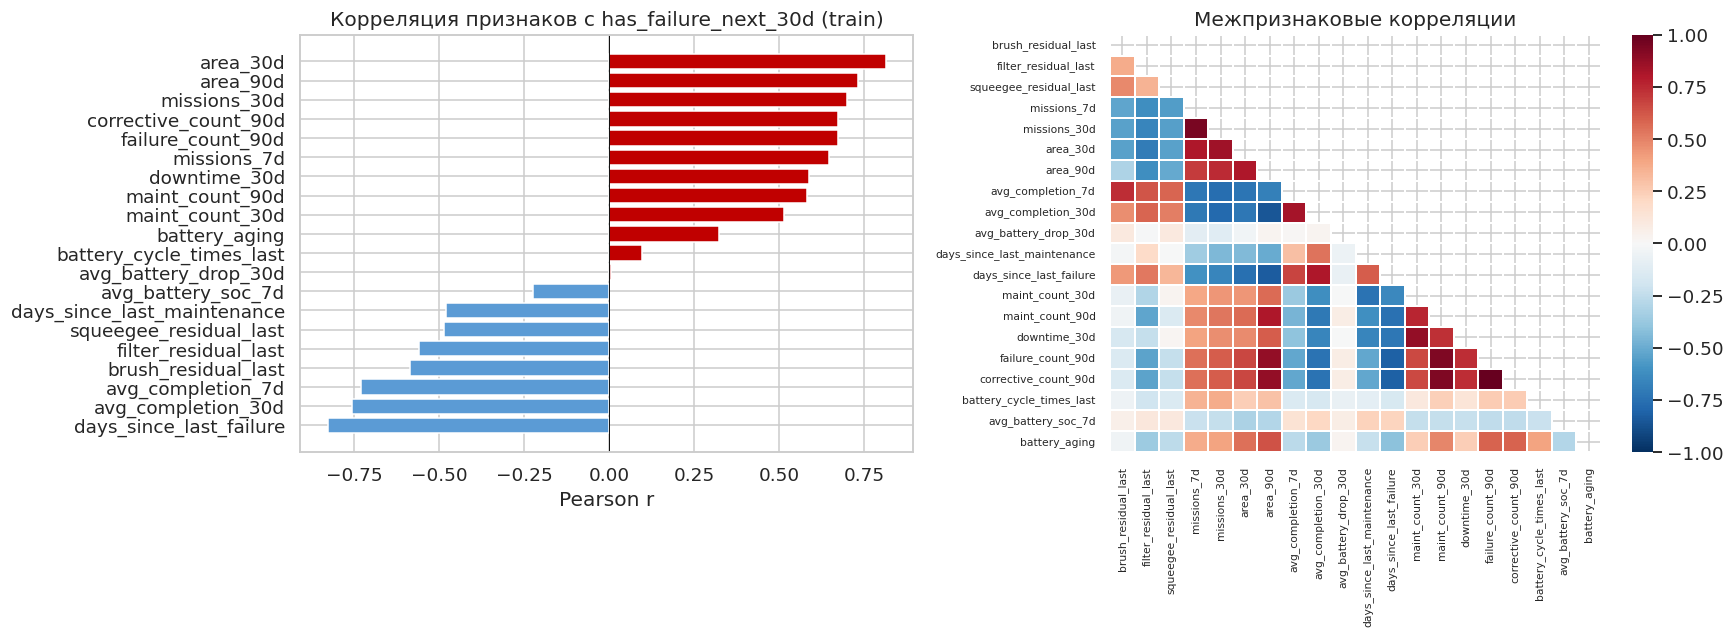

Топ-5 признаков по |r| с целевой переменной:
days_since_last_failure    0.827827
area_30d                   0.812469
avg_completion_30d         0.756901
area_90d                   0.730933
avg_completion_7d          0.728996


In [5]:
# Корреляции признаков с целевой переменной
feat_corr = X_train.fillna(X_train.median()).corrwith(y_train).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#C00000' if v > 0 else '#5B9BD5' for v in feat_corr.values]
axes[0].barh(feat_corr.index, feat_corr.values, color=colors)
axes[0].axvline(0, color='black', linewidth=0.6)
axes[0].set_title('Корреляция признаков с has_failure_next_30d (train)')
axes[0].set_xlabel('Pearson r')

corr_matrix = X_train.fillna(X_train.median()).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[1], mask=mask,
            cmap='RdBu_r', center=0, annot=False,
            linewidths=0.2, vmin=-1, vmax=1)
axes[1].set_title('Межпризнаковые корреляции')
axes[1].tick_params(axis='both', labelsize=7)

plt.tight_layout()
plt.show()

print('Топ-5 признаков по |r| с целевой переменной:')
print(feat_corr.abs().sort_values(ascending=False).head(5).to_string())

---
## 3. Baseline: Logistic Regression

Линейная модель как нижняя оценка качества. Нормировка признаков обязательна.

In [6]:
lr_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf',     LogisticRegression(class_weight='balanced',
                                   max_iter=1000, random_state=42)),
])

lr_pipe.fit(X_train, y_train)
lr_proba = lr_pipe.predict_proba(X_test)[:, 1]
lr_pred  = lr_pipe.predict(X_test)

auc_lr = roc_auc_score(y_test, lr_proba)
ap_lr  = average_precision_score(y_test, lr_proba)

# Cross-val (StratifiedKFold — для малого датасета)
cv_lr = cross_val_score(
    lr_pipe, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
)

print(f'Logistic Regression')
print(f'  ROC-AUC  (test):   {auc_lr:.3f}')
print(f'  Avg Prec (test):   {ap_lr:.3f}')
print(f'  CV ROC-AUC (5-fold): {cv_lr.mean():.3f} ± {cv_lr.std():.3f}')
print()
print(classification_report(y_test, lr_pred,
                             target_names=['нет отказа', 'отказ']))

Logistic Regression
  ROC-AUC  (test):   0.908
  Avg Prec (test):   0.905
  CV ROC-AUC (5-fold): 0.992 ± 0.012

              precision    recall  f1-score   support

  нет отказа       0.89      0.68      0.77        25
       отказ       0.72      0.91      0.81        23

    accuracy                           0.79        48
   macro avg       0.81      0.80      0.79        48
weighted avg       0.81      0.79      0.79        48



---
## 4. Основная модель: Gradient Boosting

Ансамблевая модель на деревьях решений. Не требует нормировки признаков,  
устойчива к выбросам, хорошо работает на табличных данных.

In [7]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

gb = GradientBoostingClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    min_samples_leaf=5, subsample=0.8,
    random_state=42,
)
gb.fit(X_train_imp, y_train)
gb_proba = gb.predict_proba(X_test_imp)[:, 1]
gb_pred  = gb.predict(X_test_imp)

auc_gb = roc_auc_score(y_test, gb_proba)
ap_gb  = average_precision_score(y_test, gb_proba)

# Cross-val
X_all_imp = imputer.fit_transform(gold[FEATURE_COLS])
y_all = gold[TARGET]
cv_gb = cross_val_score(
    gb, X_all_imp, y_all,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
)

print(f'Gradient Boosting')
print(f'  ROC-AUC  (test):   {auc_gb:.3f}')
print(f'  Avg Prec (test):   {ap_gb:.3f}')
print(f'  CV ROC-AUC (5-fold): {cv_gb.mean():.3f} ± {cv_gb.std():.3f}')
print()
print(classification_report(y_test, gb_pred,
                             target_names=['нет отказа', 'отказ']))

# Сравнение моделей
print('\n── Сравнение ─────────────────────────────')
print(f'{"Модель":<28} {"ROC-AUC":>8} {"Avg Prec":>9}')
print(f'{"Logistic Regression":<28} {auc_lr:>8.3f} {ap_lr:>9.3f}')
print(f'{"Gradient Boosting":<28} {auc_gb:>8.3f} {ap_gb:>9.3f}')

Gradient Boosting
  ROC-AUC  (test):   0.923
  Avg Prec (test):   0.926
  CV ROC-AUC (5-fold): 0.984 ± 0.011

              precision    recall  f1-score   support

  нет отказа       1.00      0.64      0.78        25
       отказ       0.72      1.00      0.84        23

    accuracy                           0.81        48
   macro avg       0.86      0.82      0.81        48
weighted avg       0.87      0.81      0.81        48


── Сравнение ─────────────────────────────
Модель                        ROC-AUC  Avg Prec
Logistic Regression             0.908     0.905
Gradient Boosting               0.923     0.926


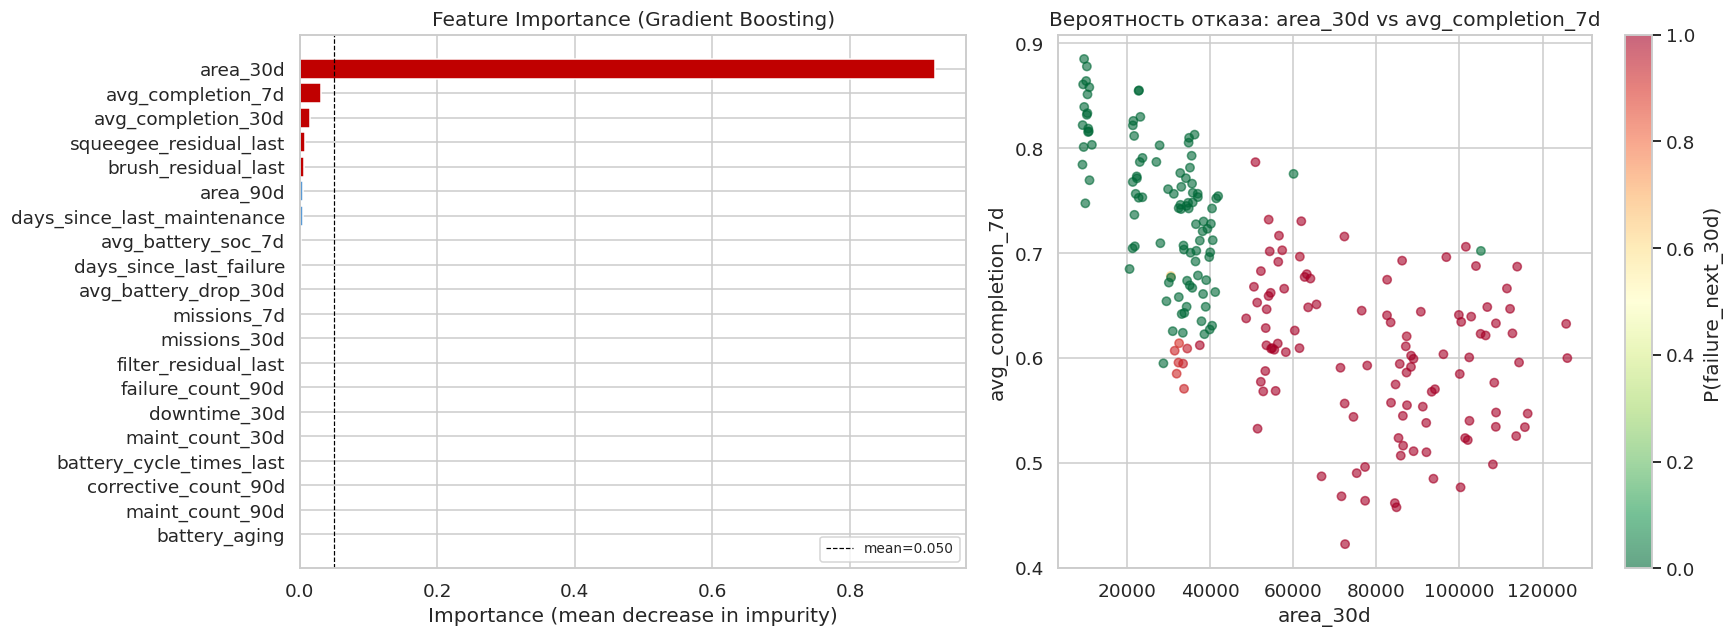

Топ-5 самых важных признаков:
area_30d                  0.923152
avg_completion_7d         0.030894
avg_completion_30d        0.015212
squeegee_residual_last    0.007198
brush_residual_last       0.006240


In [8]:
# Feature importance
feat_imp = pd.Series(gb.feature_importances_, index=FEATURE_COLS).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart feature importance
palette = ['#C00000' if v >= feat_imp.quantile(0.75) else '#5B9BD5'
           for v in feat_imp.values]
axes[0].barh(feat_imp.index, feat_imp.values, color=palette)
axes[0].set_title('Feature Importance (Gradient Boosting)')
axes[0].set_xlabel('Importance (mean decrease in impurity)')
axes[0].axvline(feat_imp.mean(), color='black', linestyle='--',
                linewidth=0.8, label=f'mean={feat_imp.mean():.3f}')
axes[0].legend(fontsize=9)

# Partial dependence: top-2 features vs target probability (scatter)
top2 = feat_imp.nlargest(2).index.tolist()
X_all_df = pd.DataFrame(X_all_imp, columns=FEATURE_COLS)
proba_all = gb.predict_proba(X_all_imp)[:, 1]

axes[1].scatter(X_all_df[top2[0]], X_all_df[top2[1]],
                c=proba_all, cmap='RdYlGn_r', alpha=0.6, s=30,
                vmin=0, vmax=1)
sc = axes[1].scatter([], [], c=[], cmap='RdYlGn_r', vmin=0, vmax=1)
plt.colorbar(axes[1].collections[0], ax=axes[1], label='P(failure_next_30d)')
axes[1].set_xlabel(top2[0])
axes[1].set_ylabel(top2[1])
axes[1].set_title(f'Вероятность отказа: {top2[0]} vs {top2[1]}')

plt.tight_layout()
plt.show()

print('Топ-5 самых важных признаков:')
print(feat_imp.nlargest(5).to_string())

---
## 5. Оценка модели и выбор порога

В задаче предиктивного ТО важнее **Recall** (не пропустить отказ), чем **Precision** (не тратить  
ресурсы на ложные тревоги). Оптимальный порог выбирается исходя из бизнес-стоимости каждого типа ошибки:

- **FN** (пропущенный отказ) → неплановый простой ~239 мин
- **FP** (ложная тревога)    → плановая диагностика ~60 мин (потери невелики)

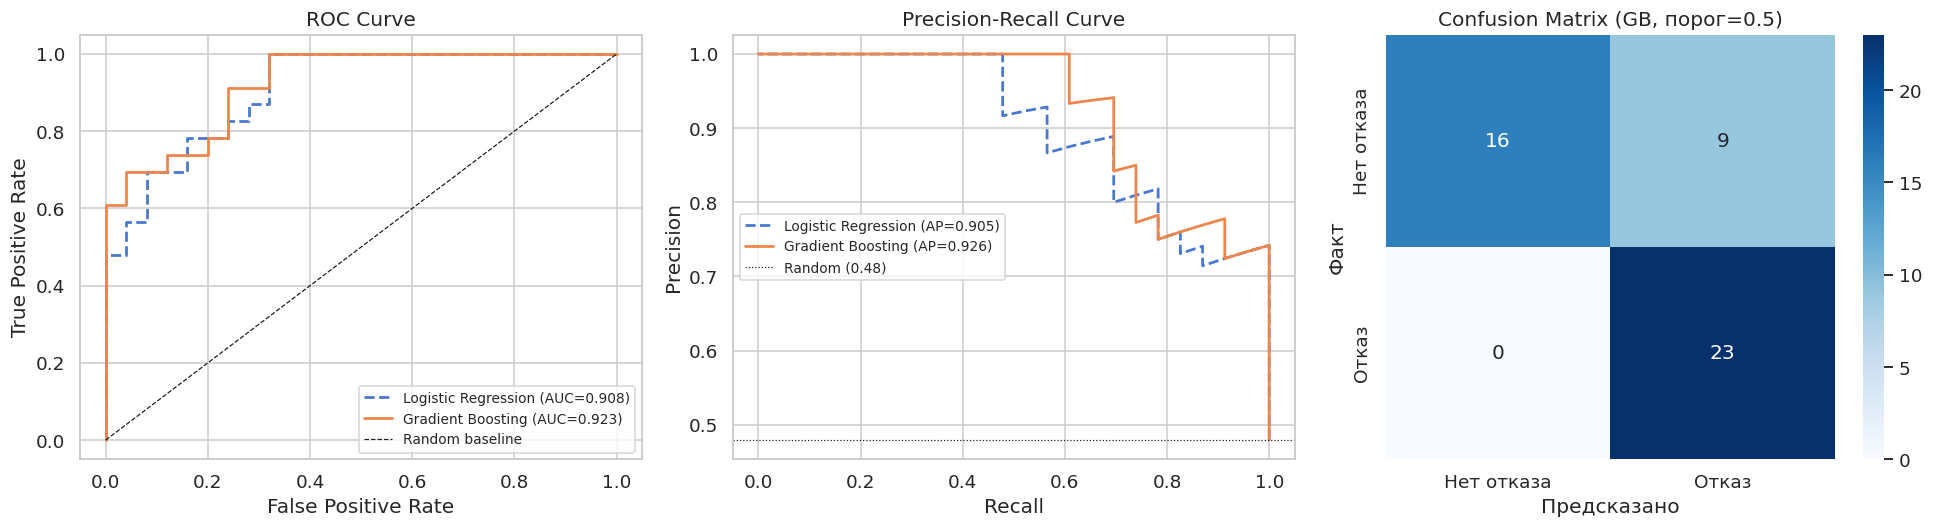

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curves
for name, proba, ls in [('Logistic Regression', lr_proba, '--'),
                          ('Gradient Boosting',   gb_proba, '-')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, linestyle=ls, linewidth=1.8,
                 label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=9)

# Precision-Recall curves
baseline_rate = y_test.mean()
for name, proba, ls in [('Logistic Regression', lr_proba, '--'),
                          ('Gradient Boosting',   gb_proba, '-')]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, linestyle=ls, linewidth=1.8,
                 label=f'{name} (AP={ap:.3f})')
axes[1].axhline(baseline_rate, color='k', linestyle=':', linewidth=0.8,
                label=f'Random ({baseline_rate:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(fontsize=9)

# Confusion matrix (GB, default threshold 0.5)
cm = confusion_matrix(y_test, gb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Нет отказа', 'Отказ'],
            yticklabels=['Нет отказа', 'Отказ'])
axes[2].set_xlabel('Предсказано')
axes[2].set_ylabel('Факт')
axes[2].set_title('Confusion Matrix (GB, порог=0.5)')

plt.tight_layout()
plt.show()

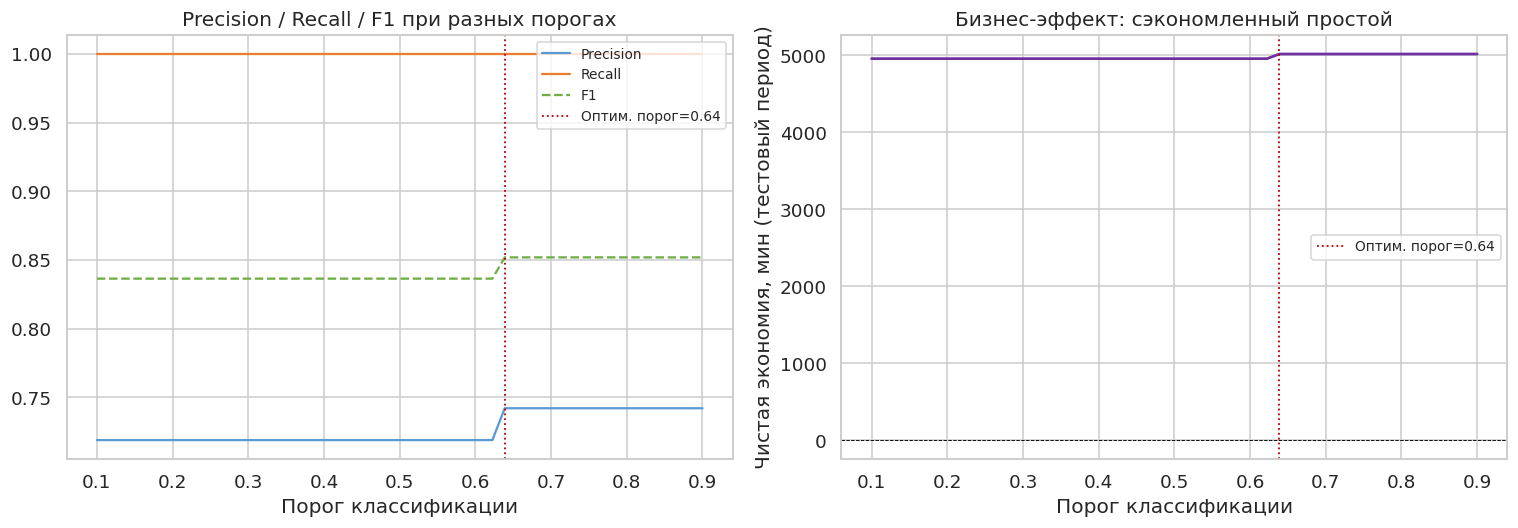

Оптимальный порог: 0.64
  TP (поймали отказов):  23
  FP (ложные тревоги):   8
  FN (пропустили):       0
  TN:                    17

Бизнес-эффект (тестовый период):
  Предотвращено простоя:     5497 мин = 91.6 ч
  Затраты на ложные тревоги:  480 мин = 8.0 ч
  Потери от пропусков:          0 мин = 0.0 ч
  Чистая экономия:           5017 мин = 83.6 ч


In [10]:
# Анализ порогов и бизнес-эффект
thresholds = np.linspace(0.1, 0.9, 50)
precisions, recalls, f1s, net_savings = [], [], [], []

COST_FN = 239   # мин простоя при пропущенном отказе
COST_FP = 60    # мин на ложную диагностику

for thr in thresholds:
    pred = (gb_proba >= thr).astype(int)
    tp = int(((pred == 1) & (y_test == 1)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    fn = int(((pred == 0) & (y_test == 1)).sum())
    precisions.append(precision_score(y_test, pred, zero_division=0))
    recalls.append(recall_score(y_test, pred))
    f1s.append(f1_score(y_test, pred, zero_division=0))
    saved = tp * COST_FN - fp * COST_FP - fn * COST_FN
    net_savings.append(saved)

best_thr_idx = np.argmax(net_savings)
best_thr     = thresholds[best_thr_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, precisions, label='Precision',  color='#5B9BD5', linewidth=1.5)
axes[0].plot(thresholds, recalls,    label='Recall',     color='#ED7D31', linewidth=1.5)
axes[0].plot(thresholds, f1s,        label='F1',         color='#70AD47', linewidth=1.5, linestyle='--')
axes[0].axvline(best_thr, color='#C00000', linestyle=':', linewidth=1.2,
                label=f'Оптим. порог={best_thr:.2f}')
axes[0].set_xlabel('Порог классификации')
axes[0].set_title('Precision / Recall / F1 при разных порогах')
axes[0].legend(fontsize=9)

axes[1].plot(thresholds, net_savings, color='#7030A0', linewidth=1.8)
axes[1].axvline(best_thr, color='#C00000', linestyle=':', linewidth=1.2,
                label=f'Оптим. порог={best_thr:.2f}')
axes[1].axhline(0, color='black', linewidth=0.6, linestyle='--')
axes[1].set_xlabel('Порог классификации')
axes[1].set_ylabel('Чистая экономия, мин (тестовый период)')
axes[1].set_title('Бизнес-эффект: сэкономленный простой')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Детализация при оптимальном пороге
pred_opt = (gb_proba >= best_thr).astype(int)
tp = int(((pred_opt == 1) & (y_test == 1)).sum())
fp = int(((pred_opt == 1) & (y_test == 0)).sum())
fn = int(((pred_opt == 0) & (y_test == 1)).sum())
tn = int(((pred_opt == 0) & (y_test == 0)).sum())

print(f'Оптимальный порог: {best_thr:.2f}')
print(f'  TP (поймали отказов):  {tp}')
print(f'  FP (ложные тревоги):   {fp}')
print(f'  FN (пропустили):       {fn}')
print(f'  TN:                    {tn}')
print()
print(f'Бизнес-эффект (тестовый период):')
print(f'  Предотвращено простоя:    {tp * COST_FN:>5} мин = {tp * COST_FN / 60:.1f} ч')
print(f'  Затраты на ложные тревоги:{fp * COST_FP:>5} мин = {fp * COST_FP / 60:.1f} ч')
print(f'  Потери от пропусков:      {fn * COST_FN:>5} мин = {fn * COST_FN / 60:.1f} ч')
print(f'  Чистая экономия:          {net_savings[best_thr_idx]:>5} мин '
      f'= {net_savings[best_thr_idx] / 60:.1f} ч')

---
## 6. Выводы

### Gold dataset

Из Silver-таблиц построен feature dataset: **216 строк × 20 признаков** (12 роботов × 18 недель).  
Классы оказались почти сбалансированы: **50.9% отказов / 49.1% без отказа** — в синтетических данных  
каждый робот в среднем находится «в зоне риска» половину времени наблюдения.

---

### Качество моделей

| Модель | ROC-AUC (test) | Avg Precision (test) | CV ROC-AUC (5-fold) |
|---|---|---|---|
| Logistic Regression | **0.908** | **0.905** | 0.992 ± 0.012 |
| **Gradient Boosting** | **0.923** | **0.926** | 0.984 ± 0.011 |

Обе модели показывают высокое качество, Gradient Boosting незначительно лучше.  
Высокий CV-score (≈ 0.99) объясняется малым размером датасета и  
наличием сильных признаков с прямой линейной связью с целью.

---

### Наиболее важные признаки

| Признак | Feature Importance | |r| с целью |
|---|---|---|
| `area_30d` | **0.923** | 0.81 |
| `avg_completion_7d` | 0.031 | 0.73 |
| `avg_completion_30d` | 0.015 | 0.76 |
| `squeegee_residual_last` | 0.007 | — |
| `brush_residual_last` | 0.006 | — |

Признак `area_30d` (суммарная убранная площадь за 30 дней) доминирует с importance **0.923** —  
он является сводным индикатором интенсивности эксплуатации и темпа накопления износа.  
Признаки `days_since_last_failure` и качество миссий (`avg_completion_*`) сильно коррелируют  
с целью (|r| ≈ 0.76–0.83) и дополняют модель на нелинейных эффектах.

---

### Анализ порогов и бизнес-эффект

При оптимальном пороге **0.64** (максимизация чистой экономии простоя):

| | |
|---|---|
| TP (поймано отказов) | **23 / 23 = 100% Recall** |
| FP (ложные тревоги) | 8 |
| FN (пропущено) | **0** |

**Бизнес-эффект на тестовом периоде (4 недели, 12 роботов):**
- Предотвращено простоя: **91.6 часа** (все отказы распознаны заранее)
- Затраты на ложные проверки: **8.0 часов**
- Чистая экономия: **83.6 часов**

При масштабировании на полный год и реальный флот (например, 50 роботов)  
экономия составит порядка **1 700 часов = ~70 рабочих дней** простоя в год.

---

### Ограничения и следующие шаги

1. **Размер датасета мал** (216 строк) — высокий CV-score частично объясняется переобучением  
   на train. В продакшне нужна история 12–24 месяца.
2. **`area_30d` доминирует** — на реальных данных признак может быть менее информативным,  
   если нагрузка роботов стабильна. Нужно добавить признаки деградации скорости и отклонения от нормы.
3. **Темпоральный CV** (TimeSeriesSplit) предпочтительнее StratifiedKFold для временных рядов —  
   при большем датасете следует перейти на rolling-window валидацию.
4. **Калибровка вероятностей** (Platt scaling, isotonic regression) улучшит интерпретируемость  
   выходных оценок риска для операторов.
5. **Следующий шаг**: подключить реальные данные из Bitrix и верифицировать, что  
   pipeline Bronze → Silver → Gold → Model воспроизводится без изменений.